In [1]:
#import general packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler


from astropy.table import Table, join
import astropy.units as u
from scipy.optimize import curve_fit


#import LSST packages
from lsst.rsp import get_tap_service
import lsst.daf.butler as dafButler
from lsst.geom import LinearTransform, radians
from lsst.afw.geom import Quadrupole, Ellipse

def apply_filter(wvl, data, band = 'g', rm_leakage = True):
    '''
    wvl - a list of the wavelengths in angstroms
    data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
    returns data with the band filter applied to each SED
    '''

    
    filter_file = f'/home/msredden/DATA/filters/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    # remove filter leakage: set lower bound of filter to 0.001 throughput
    if rm_leakage:
        leakage_mask = filter_band[1] < 0.001
        filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
    func = interp1d(filter_band[0], filter_band[1])
    SED_filter = func(wvl)
    
    return data * SED_filter

def rebin(x, y, stepsize = None, newx_edges = None):

    if newx_edges is None:        
        newx_edges = np.arange(min(x), max(x) + stepsize, stepsize)
    
    newx = newx_edges[0:-1] + (newx_edges[1:] - newx_edges[0:-1])/2
        

    binned_data = np.zeros(len(newx_edges) - 1)    
    binned_err = np.zeros(len(newx_edges) - 1)

    bin_ind = np.digitize(x, newx_edges) - 1
    
    for i in range(len(binned_data)):
        mask = bin_ind == i
        newx[i] = np.mean(x[mask])
        binned_data[i] = np.mean(y[mask])
        binned_err[i] = np.std(y[mask])/np.sqrt(np.sum(mask))

    return newx, binned_data, binned_err

In [2]:
# load previously queried data/table products
# %store -r source_table1 source_table2 source_table3 master
# source_table = Table.read('source_table_NOTused.ecsv')
# master = Table.read('master_NOTused.ecsv')

In [3]:
from astropy.table import vstack
# source_table = vstack([source_table1, source_table2, source_table3])

# print(source_table.keys())
# print(master.keys())
# master.write("master_NOTused.ecsv")
# print(type(source_table))
# print(type(master))

In [4]:
#define object search

query = """SELECT coord_dec,
            coord_ra,
            deblend_nChild,
            detect_fromBlend,
            detect_isIsolated,
            g_cModelMag,
            g_cModelMagErr,
            g_psfMag,
            g_psfMagErr,
            i_cModelMag,
            i_cModelMagErr,
            i_psfMag,
            i_psfMagErr,
            objectId,
            parentObjectId, 
            patch,
            r_cModelMag,
            r_cModelMagErr,
            r_psfMag,
            r_psfMagErr,
            refBand,
            refExtendedness,
            refSizeExtendedness,
            shape_xx,
            shape_xy,
            shape_yy,
            tract,
            u_cModelMag,
            u_cModelMagErr,
            u_psfMag,
            u_psfMagErr,
            y_cModelMag,
            y_cModelMagErr,
            y_psfMag,
            y_psfMagErr,
            z_cModelMag,
            z_cModelMagErr,
            z_psfMag,
            z_psfMagErr 
    FROM dp1.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.0871733, -28.0878248, 0.3))=1
      AND (g_cModelMag < 22 AND g_cModelMag > 18
           AND shape_xy < 0.05 AND shape_xy > -0.05
           AND (shape_xx - shape_yy) < 0.1 AND (shape_xx - shape_yy) > 0.1)"""


# query_simple looks for stars (refExtendedness = 0.0) in the ECDFS

query_simple = """SELECT coord_dec,
            coord_ra,
            g_cModelMag,
            shape_xx,
            shape_xy,
            shape_yy,
            refExtendedness,
            detect_isIsolated
    FROM dp1.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.0871733, -28.0878248, 0.3))=1
      AND (g_cModelMag < 24.5 AND g_cModelMag > 22)
           AND refExtendedness = 0.0
           AND detect_isIsolated = 1"""

query_simple = """SELECT coord_dec,
            coord_ra,
            g_cModelMag,
            r_cModelMag,
            i_cModelMag,
            u_cModelMag,
            z_cModelMag,
            shape_xx,
            shape_xy,
            shape_yy,
            refExtendedness,
            g_calib_psf_reserved,
            g_calib_psf_used,
            g_cModelMag - r_cModelMag as grColor,
            g_cModelMag - i_cModelMag as giColor,
            r_cModelMag - z_cModelMag as rzColor,
            u_cModelMag - g_cModelMag as ugColor
    FROM dp1.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.13, -28.10, 3600/3600))=1
            AND (g_cModelMag < 23 AND g_cModelMag > 18)
            AND refExtendedness = 0
            """

# AND g_calib_psf_used = 0
 #AND (g_cModelMag < 23 AND g_cModelMag > 18)
           # AND refExtendedness = 0.0
field_centers = {
    "47 Tuc": [6.02, -72.08],
    "SV 38 7": [37.86, 6.98],
    "Fornax": [40.00, -34.45],
    "ECDFS": [53.13, -28.10],
    "EDFS": [59.10, -48.73],
    "SV 95 -25": [95.00, -25.00],
    "Seagull": [106.23, -10.51],
}

#  AND (r_cModelMag - g_cModelMag) > 0

service = get_tap_service("tap")
job = service.submit_job(query_simple)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
object_table = job.fetch_result().to_table()

print(len(object_table))

Job phase is COMPLETED
3257


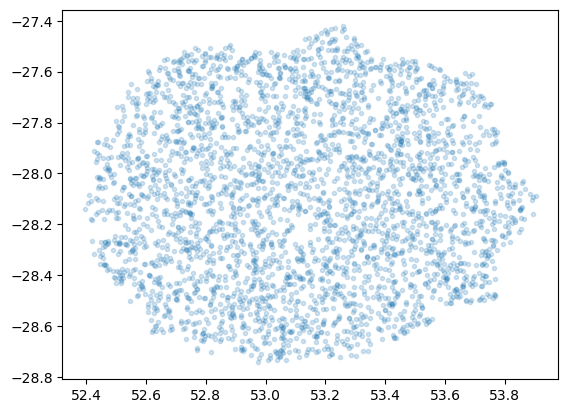

In [5]:
plt.scatter(object_table['coord_ra'], object_table['coord_dec'], marker = '.', alpha = 0.2)

-59.02055358886719 1.8445549011230469
3095


Text(0, 0.5, 'counts')

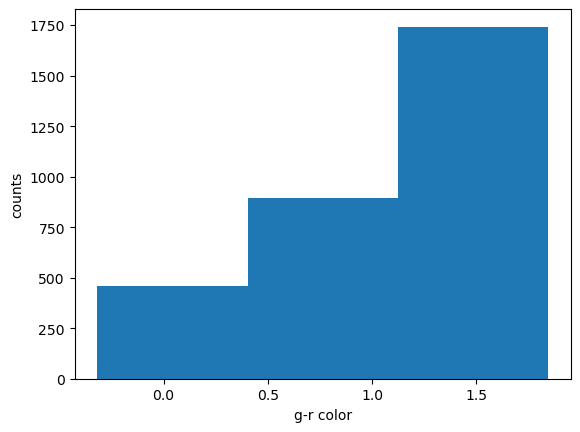

In [6]:
#determine color cuts
mask = np.isnan(object_table['grColor'])
print(min(object_table['grColor'][~mask]), max(object_table['grColor'][~mask]))

mask2 = (object_table['grColor'] > -3) * (object_table['grColor'] < 3)
print(np.sum(mask2))


plt.hist(object_table['grColor'][mask2],3)
# plt.hist(object_table['grColor'], bins = [-0.3,  0.4,  1.0,  1.5], color =['C0', 'C1', 'C2'], edgecolor = 'k')
# plt.hist(object_table['grColor'][mask2], bins = np.linspace(-0.5, 2.5, 10))
# plt.hist(object_table['grColor'][object_table['grColor'] < 0.5], bins = [-0.5,  0.5,  1.0,  2], color ='C0')
# plt.hist(object_table['grColor'][(object_table['grColor'] > 0.5) * (object_table['grColor'] < 1.2)], bins = [-0.5,  0.5,  1.2,  2], color ='C1')
# plt.hist(object_table['grColor'][object_table['grColor'] > 1.2], bins = [-0.5,  0.5,  1.2,  2], color ='C2')
plt.xlabel('g-r color')
plt.ylabel('counts')


In [7]:
#source query
search_radius = 2 #arcsec
search_circles = [f"CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1" for ra, dec in np.array([object_table['coord_ra'], object_table['coord_dec']]).T]
search_string = " OR ".join(map(str, search_circles))

source_query = f"""SELECT band,
            coord_dec,
            coord_ra,
            dec,
            decErr,
            detector,
            ixx,
            ixxPSF,
            ixy,
            ixyPSF,
            iyy,
            iyyPSF,
            ra,
            raErr,
            visit,
            psfFlux,
            psfFluxErr
            
    FROM dp1.Source 
    WHERE (band = 'g' OR band = 'i' or band = 'u' or band = 'r' or band = 'z') AND ({search_string})
    AND psfFluxErr / psfFlux < 0.05
    """

    # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) > -0.02
    # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) < 0.02

            # (ixx - iyy) / (ixx + iyy) AS e1,
            # (2*ixy) / (ixx + iyy) AS e2,
            # (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) AS e1PSF,
            # (2*ixyPSF) / (ixxPSF + iyyPSF) AS e2PSF

# job = service.submit_job(source_query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# source_table = job.fetch_result().to_table()
# print(len(source_table))
# print('u band sources returned', np.sum(source_table['band'] == 'u'))
# print('g band sources returned', np.sum(source_table['band'] == 'g'))
# print('r band sources returned', np.sum(source_table['band'] == 'r'))
# print('i band sources returned', np.sum(source_table['band'] == 'i'))
# print('z band sources returned', np.sum(source_table['band'] == 'z'))


In [8]:
# for separating by color
#source query
def source_query(coords):
    search_radius = 2 #arcsec
    search_circles = [f"CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1" for ra, dec in np.array([coords['coord_ra'], coords['coord_dec']]).T]
    search_string = " OR ".join(map(str, search_circles))
    
    source_query = f"""SELECT band,
                coord_dec,
                coord_ra,
                dec,
                decErr,
                detector,
                ixx,
                ixxPSF,
                ixy,
                ixyPSF,
                iyy,
                iyyPSF,
                ra,
                raErr,
                visit,
                psfFlux,
                psfFluxErr
                
        FROM dp1.Source 
        WHERE (band = 'g' OR band = 'i' or band = 'u' or band = 'r' or band = 'z') AND ({search_string})
        AND psfFluxErr / psfFlux < 0.05
        """
    
        # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) > -0.02
        # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) < 0.02
    
                # (ixx - iyy) / (ixx + iyy) AS e1,
                # (2*ixy) / (ixx + iyy) AS e2,
                # (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) AS e1PSF,
                # (2*ixyPSF) / (ixxPSF + iyyPSF) AS e2PSF
    
    job = service.submit_job(source_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    source_table = job.fetch_result().to_table()
    return source_table

grbin1_coords = object_table['coord_ra', 'coord_dec'][(object_table['grColor'] > -0.5) * (object_table['grColor'] < 0.5)]
grbin2_coords = object_table['coord_ra', 'coord_dec'][(object_table['grColor'] > 0.5) * (object_table['grColor'] < 1.2)]
grbin3_coords = object_table['coord_ra', 'coord_dec'][(object_table['grColor'] > 1.2 ) *(object_table['grColor'] < 2.0)]

# source_table1 = source_query(grbin1_coords)
# source_table1['grbin'] = np.ones(len(source_table1))
# %store source_table1
# source_table1.write("source_table1_ALL.ecsv")

# source_table2 = source_query(grbin2_coords)
# source_table2['grbin'] = np.ones(len(source_table2)) * 2
# %store source_table2
# source_table2.write("source_table2_ALL.ecsv")

# source_table3 = source_query(grbin3_coords)
# source_table3['grbin'] = np.ones(len(source_table3)) * 3
# %store source_table3


# source_table3.write("source_table3_ALL.ecsv")

# %store -r source_table1, source_table2, source_table3

source_table1 = Table.read('source_table1_ALL.ecsv')
source_table2 = Table.read('source_table2_ALL.ecsv')
source_table3 = Table.read('source_table3_ALL.ecsv')

from astropy.table import vstack
source_table = vstack([source_table1, source_table2, source_table3])

# %store source_table

print(len(source_table))
print('u band sources returned', np.sum(source_table['band'] == 'u'))
print('g band sources returned', np.sum(source_table['band'] == 'g'))
print('r band sources returned', np.sum(source_table['band'] == 'r'))
print('i band sources returned', np.sum(source_table['band'] == 'i'))
print('z band sources returned', np.sum(source_table['band'] == 'z'))

# %store source_table

820151
u band sources returned 9489
g band sources returned 225807
r band sources returned 249657
i band sources returned 176528
z band sources returned 158670


In [9]:
#visit table
visit_IDs = source_table['visit']

unique_visits = np.unique(visit_IDs)

visit_string = "','".join(map(str, unique_visits))

visit_query = f"""SELECT airmass,altitude,azimuth,band,dec,expTime,ra,skyRotation,visit,zenithDistance,expMidptMJD 
    FROM dp1.Visit 
    WHERE visit IN ('{visit_string}')"""


job = service.submit_job(visit_query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_table = job.fetch_result().to_table()

print(len(visit_table))

Job phase is COMPLETED
825


In [10]:
#join source and visit tables into a master table
master = join(source_table, visit_table, keys = 'visit')

In [11]:
# Add color columns from object_table to master by coordinate matching.
# Uses search_around_sky for a fully vectorized cross-match (no iteration over master).
# Master rows within 2" of more than one object_table entry get NaN colors.

from astropy.coordinates import SkyCoord, search_around_sky

master_coords = SkyCoord(ra=np.array(master['ra_1']) * u.deg, dec=np.array(master['dec_1']) * u.deg)
object_coords = SkyCoord(ra=np.array(object_table['coord_ra']) * u.deg, dec=np.array(object_table['coord_dec']) * u.deg)

# All (master, object) pairs within 2 arcsec
idx_master, idx_obj, sep2d, _ = search_around_sky(master_coords, object_coords, 2 * u.arcsec)

# Find which master indices appear more than once (ambiguous matches)
unique_master_ids, counts = np.unique(idx_master, return_counts=True)
single_match_ids = unique_master_ids[counts == 1]

# Keep only pairs where the master row has exactly one match
keep = np.isin(idx_master, single_match_ids)
idx_master_unique = idx_master[keep]
idx_obj_unique = idx_obj[keep]

# Add color columns to master, NaN by default
color_cols = ['grColor', 'giColor', 'rzColor', 'ugColor']
for col in color_cols:
    col_data = np.full(len(master), np.nan)
    col_data[idx_master_unique] = np.array(object_table[col])[idx_obj_unique]
    master[col] = col_data

print(f"Total master rows:        {len(master)}")
print(f"Uniquely matched:         {len(idx_master_unique)}")
print(f"Ambiguous (NaN colors):   {int(np.sum(counts > 1))}")
print(f"Unmatched (no object):    {len(master) - len(unique_master_ids)}")

Total master rows:        820151
Uniquely matched:         816423
Ambiguous (NaN colors):   3728
Unmatched (no object):    0


In [12]:
# Don't use this it's super slow. Use the following cell instead

# # add parallactic angle column to the source table

# from rotateMoments import parallactic_angle_from_radec

# # Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

# # Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction
# # master['q'] = np.zeros(len(master))
# # master['r_z'] = np.zeros(len(master))

# for i in range(5):
#     ra, dec, mjd = master['ra_1', 'dec_1', 'expMidptMJD'][i]
#     par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat =  lat * u.deg, lon = lon * u.deg,height =  height * u.m)
#     # master['q'][i] = par.value
#     print(par)


#     # dra = ra - center_ra
#     # ddec = dec - center_dec
#     # cq, sq = np.cos(par.value), np.sin(par.value)
#     # R = np.array([[cq, sq], [-sq, cq]])
#     # dt, dz = R.T @ [dra, ddec]
#     # master['r_z'][i] = dz


print(master[0])


band_1      coord_dec           coord_ra             dec_1           decErr   detector        ixx               ixxPSF             ixy                ixyPSF              iyy               iyyPSF              ra_1           raErr        visit          psfFlux           psfFluxErr    grbin     airmass          altitude         azimuth      band_2       dec_2       expTime       ra_2         skyRotation      zenithDistance      expMidptMJD          grColor             giColor            rzColor            ugColor      
               deg                deg                 deg             deg                     pix2               pix2              pix2                pix2               pix2               pix2               deg             deg                          nJy                nJy                                     deg              deg                      deg           s          deg              deg               deg                 d                                           

In [13]:
# parallel parallactic angle calculation
from astropy.coordinates import EarthLocation, Angle
from astropy.time import Time

# # Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

loc = EarthLocation(lat = lat * u.deg, lon = lon * u.deg, height = height * u.m)

times = Time(master['expMidptMJD'], format = 'mjd', scale = 'utc')
lst = times.sidereal_time(kind = 'mean', longitude = loc.lon)
HA = (lst - Angle(list(master['ra_1'])* u.deg)).wrap_at(180*u.deg)


H_rad = HA.to(u.rad).value
phi = Angle(lat * u.deg).to(u.rad).value #lat * np.pi/180
delta = Angle(np.array(master['dec_1'])*u.deg).to(u.rad).value #np.array(master['dec_1']) * np.pi/180

numerator = np.sin(H_rad)
denominator = np.tan(phi) * np.cos(delta) - np.sin(delta) * np.cos(H_rad)

q_rad = np.arctan2(numerator, denominator)   # result in radians
q = q_rad * u.rad

# normalize to (-180,180] or whatever you prefer — here we return angle wrapped to [-180,180)
q = Angle(q).wrap_at(360*u.deg)


master['q'] = q.value

In [14]:
from lsst.daf.butler import Butler, Timespan
butler = Butler("dp1", collections="LSSTComCam/DP1")
from lsst.geom import LinearTransform, radians

boresightParAngles = []
boresightRotAngles = []

for i in range(5):
    visit_image = butler.get("visit_image", visit = master['visit'][i], detector = master['detector'][i])
    visitInfo = visit_image.visitInfo
    boresightParAngles.append(visitInfo.boresightParAngle.asRadians())
    boresightRotAngles.append(visitInfo.boresightRotAngle.asRadians())



In [15]:
#use this as a check to make sure the parallactic angle is being calculated correctly by comparing to the value that gets saved in the visit_image
print(np.array(boresightParAngles)*180/np.pi)
print(np.array(boresightRotAngles)*180/np.pi)

print(master['q'][0:5]*180/np.pi)
print(master['skyRotation'][0:5])


print(max(master['zenithDistance']))

[102.33220249 102.33220249 102.33220249 102.33220249 102.33220249]
[102.79937873 102.79937873 102.79937873 102.79937873 102.79937873]
        q         
------------------
102.70817361305289
102.23721249990643
 101.9665187578587
101.78144653564766
 101.7236873342518
  skyRotation   
      deg       
----------------
102.799378733233
102.799378733233
102.799378733233
102.799378733233
102.799378733233
47.8883595491108


In [16]:
# calculate the shape moments in the alt/az and ra/dec coordinate systems
from rotateMoments import rotateXYtoAA, rotateXYtoNW, rotateNWtoAA

# x/y to az/alt (first need to add telescope rotation angle to the master table):
# master['rotTelPos'] = master['q'] - master['skyRotation']*np.pi/180 - (np.pi / 2)
# aaIxx, aaIyy, aaIxy = rotateXYtoAA(master['ixx'], master['iyy'], master['ixy'], master['rotTelPos'])
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixx'], master['iyy'], master['ixy'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxx'] = aaIxx
master['aaIyy'] = aaIyy
master['aaIxy'] = aaIxy


# x/y to az/alt (first need to add telescope rotation angle to the master table):
# master['rotTelPos'] = master['q'] - master['skyRotation']*np.pi/180 - (np.pi / 2)
# aaIxx, aaIyy, aaIxy = rotateXYtoAA(master['ixxPSF'], master['iyyPSF'], master['ixyPSF'], master['rotTelPos'])
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixxPSF'], master['iyyPSF'], master['ixyPSF'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxxPSF'] = aaIxx
master['aaIyyPSF'] = aaIyy
master['aaIxyPSF'] = aaIxy



# x/y to ra and dec (n/w)
nwIxx, nwIyy, nwIxy = rotateXYtoNW(master['ixx'], master['iyy'], master['ixy'], master['skyRotation']*np.pi/180)

master['nwIxx'] = nwIxx
master['nwIyy'] = nwIyy
master['nwIxy'] = nwIxy



# optional check: ra/dec to az/alt
# aaIxx2, aaIyy2, aaIxy2 = rotateNWtoAA(nwIxx, nwIyy, nwIxy, master['q'])

print(len(master))

/home/msredden/notebooks/rotateMoments.py:126: UserWarning: Warning: converting a masked element to nan.
  shape = Quadrupole(Ixx_, Iyy[i], Ixy[i])


820151


In [17]:
# calculate e1
IzzPSF = master['aaIyyPSF'] 
IttPSF = master['aaIxxPSF']
IztPSF = master['aaIxyPSF']

e1PSF = (IttPSF - IzzPSF) / (IttPSF + IzzPSF + 2 * np.sqrt(IzzPSF * IttPSF - IztPSF**2))
e2PSF = 2*IztPSF / (IttPSF + IzzPSF + 2 * np.sqrt(IzzPSF * IttPSF - IztPSF**2))

master['e1PSF'] = e1PSF
master['e2PSF'] = e2PSF

Izz = master['aaIyy'] 
Itt = master['aaIxx']
Izt = master['aaIxy']

e1 = (Itt - Izz) / (Itt + Izz + 2 * np.sqrt(Izz * Itt - Izt**2))# - e1PSF
e2 = 2*Izt / (Itt + Izz + 2 * np.sqrt(Izz * Itt - Izt**2))

master['e1'] = e1
master['e2'] = e2

In [18]:
# %store master
# master.write('master_ALL.ecsv')


range:  nan nan


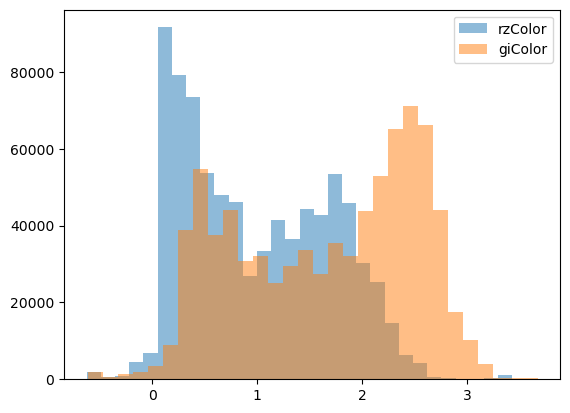

(array([191877., 339092., 275595.]), array([-0.61330414,  0.81396357,  2.24123128,  3.66849899]), <BarContainer object of 3 artists>)


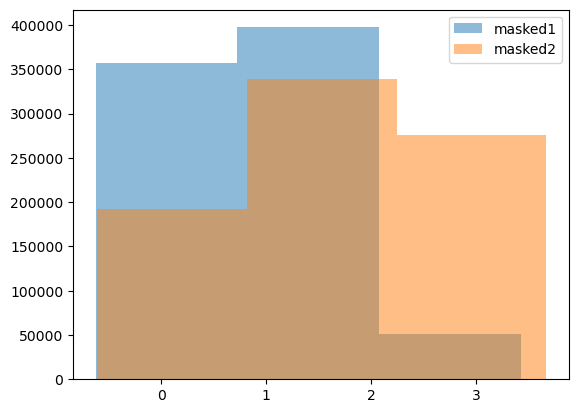

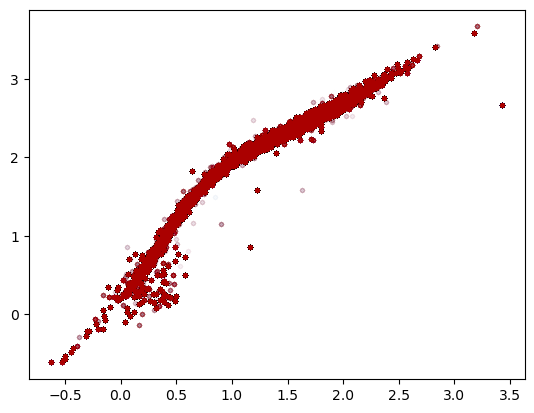

In [19]:
# plot some histograms to estimate the "quality" of the data and decide what masks need to be applied

column = 'rzColor'
column2 = 'giColor'

dat_subset = master[column]#/master[column2]
dat_subset2 = master[column2]
print('range: ', np.min(dat_subset), np.max(dat_subset))

mask = (dat_subset < 2) * (dat_subset2 < 20)
mask = ((master['raErr'] < 0.05/3600) * 
                 (master['decErr'] < 0.05/3600) * 
                 (master['psfFluxErr']/master['psfFlux'] > 0) *
                (master['ixx'] < 20)*
                 (master['iyy'] < 20))



hist = plt.hist(dat_subset, 30, alpha = 0.5, label = column)
# print(hist)
plt.hist(dat_subset2, 30, alpha = 0.5, label = column2)
plt.legend()
plt.show()
plt.close()

hist = plt.hist(dat_subset[mask], 3, alpha = 0.5, label = 'masked1')
# print(hist)
hist = plt.hist(dat_subset2[mask], 3,alpha = 0.5,  label = 'masked2')
print(hist)
plt.legend()
plt.show()
plt.close()

plt.scatter(master[column], master[column2], alpha = 0.01, marker = '.')
plt.scatter(master[column][mask], master[column2][mask], alpha = 0.01, c = 'r', marker = '.')



1308
2033
970


/tmp/ipykernel_53/2690295763.py:55: UserWarning: Warning: converting a masked element to nan.
  newx[i] = np.mean(x[mask])
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3858: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, 

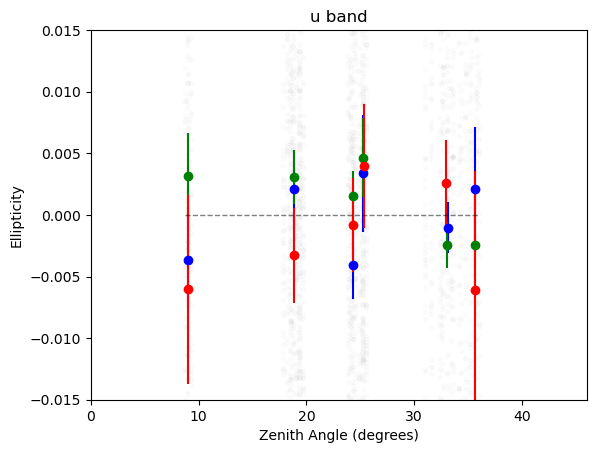

u observations: 971 total, 970 good
17094
50253
108587


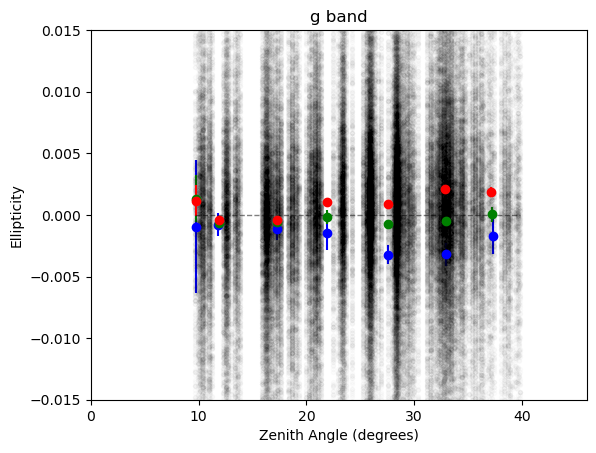

g observations: 108840 total, 108587 good
17646
54687
127310


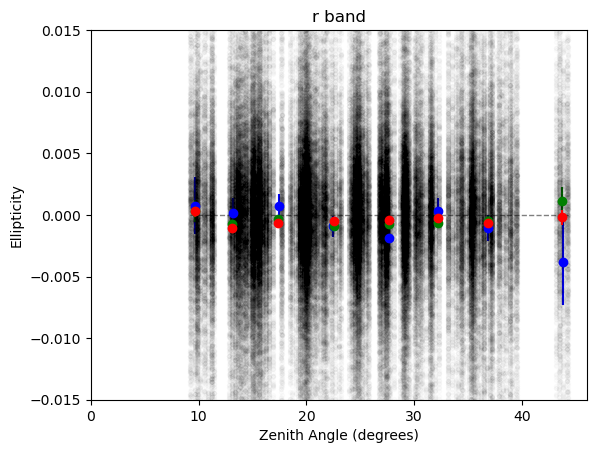

r observations: 127721 total, 127310 good
12382
38740
91160


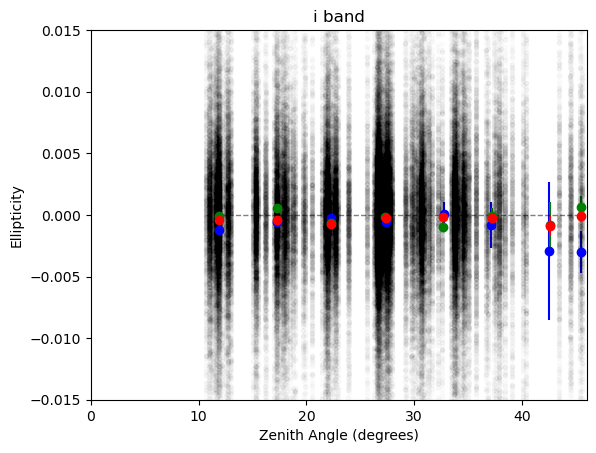

i observations: 91538 total, 91160 good
10038
34655
86551


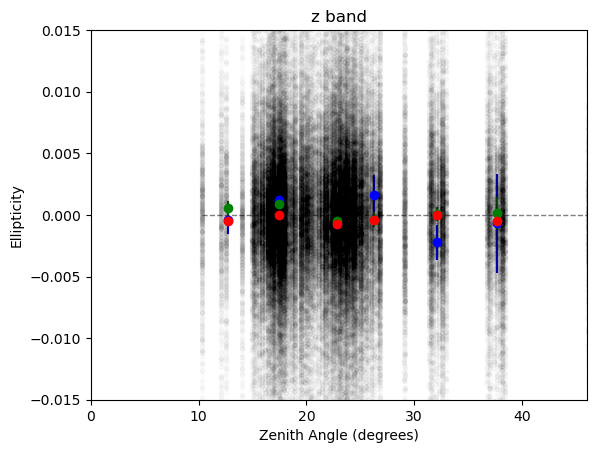

z observations: 86870 total, 86551 good


In [20]:
# Plot the moments as a function of zenith angle of the observation 

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

color_label = 'rzColor'
# color_bin_edges = {1: [-0.7, 0.4], 2: [0.4, 2.4], 3: [2.4, 3.7], 4:[2.4, 3.5]}
# color_bin_edges = {1: [-0.7, 1.0], 2: [1.0, 2.0], 3: [2.0, 4.0], 4:[2.4, 3.5]}
color_bin_edges = {1: [0.27, 0.38], 2: [0.38, 0.82], 3: [0.82, 3.5]}


# Set the default color cycle to red, green, and blue
mpl.rcParams['axes.prop_cycle'] = cycler(color=['blue', 'green', 'red'])

for band in 'ugrizy':
    band_mask = ((master['band_1'] == band) * 
                (master['raErr'] < 0.05/3600) * 
                 (master['decErr'] < 0.05/3600) * 
                 (master['psfFluxErr']/master['psfFlux'] > 0) *
                (master['ixx'] < 20)*
                 (master['iyy'] < 20))

    if np.sum(band_mask) > 0:

        for i in [1, 2, 3]:

            full_mask = band_mask * (master[color_label] > color_bin_edges[i][0]) *  (master[color_label] < color_bin_edges[i][1])
            airmass = master[full_mask]['airmass']
            z = np.arccos(1 / airmass) * 180 / np.pi
    
            e1PSF = master['e1PSF'][full_mask]
    
            # e2 = 2*Izt / (Itt + Izz + 2 * np.sqrt(Izz * Itt - Izt**2))
            
            e1 = master['e1'][full_mask] - e1PSF
            e2 = master['e2'][full_mask]
    
            # popt, pcov = curve_fit(dR_model, z, Izz)
    
            # plt.plot(z, master['r_z'][band_mask]*3600 *10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = 'Iyy (zenith axis)')
            # plt.plot(z, Itt,  ls = '', marker = '.', alpha = 0.5, color = 'k', label = 'Ixx (azimuthal axis)')
                
            plt.plot(z, e1,  ls = '', marker = '.', alpha = 0.01, color = 'k') #, label = 'e1 (zenith axis)')
            # plt.plot(z, e2,  ls = '', marker = '.', alpha = 0.01, color = 'k', label = 'e2 (azimuthal axis)')
    
            bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
            
            mask = np.isnan(e1)
            print(len(z[~mask]))
            z_bin1, e1_binned, e1_err = rebin(z[~mask], e1[~mask], newx_edges = bin_edges)
            mask = np.isnan(e2)
            z_bin2, e2_binned, e2_err = rebin(z[~mask], e2[~mask], newx_edges = bin_edges)
    
            
            plt.errorbar(z_bin1, e1_binned, yerr = e1_err, ls = '', marker = 'o', label  = f'Average e1 (bin = {i})')
            # plt.errorbar(z_bin2, e2_binned, yerr = e2_err, ls = '', marker = 'o', color = 'k', label = 'Average e2')

       
        z_temp = np.linspace(min(z), max(z), 20) 
        # plt.plot(z_temp, dR_model(z_temp, *popt) , 'k--', linewidth = 2, label = 'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)), 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        # plt.plot(zeniths, diff / 3600, 'g.-', label = 'Simulated residual of a 7500 K star (reference: 4000 K star)')
        plt.ylim(-0.015, 0.015)
        plt.xlim(0, 46)
        plt.title(f'{band} band')
        plt.xlabel('Zenith Angle (degrees)')
        plt.ylabel('Ellipticity')
        # plt.legend()
    
        plt.show()
        plt.close()

        print(f'{band} observations: {len(e1)} total, {len(e1[~np.isnan(e1)])} good')


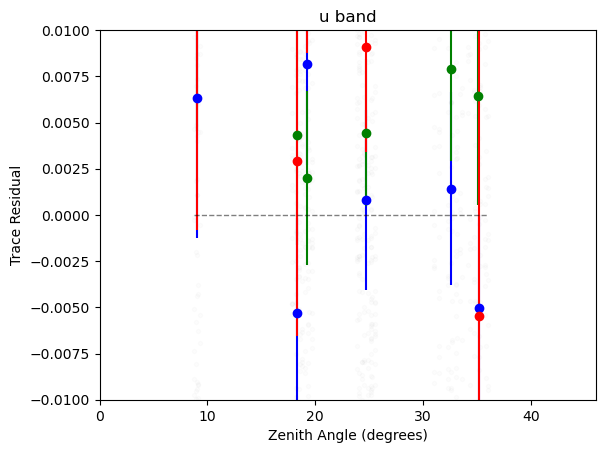

u observations: 86870 total, 86551 good


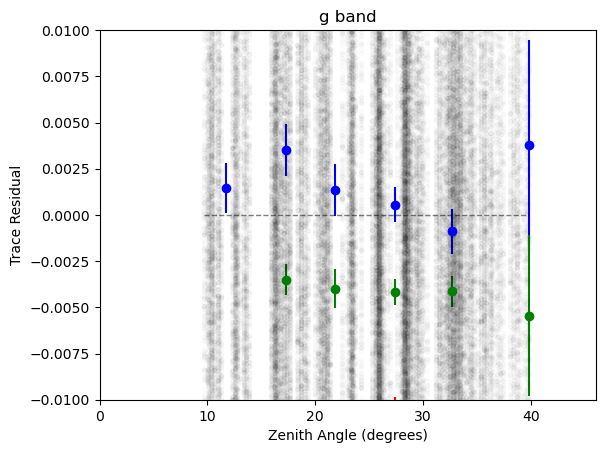

g observations: 86870 total, 86551 good


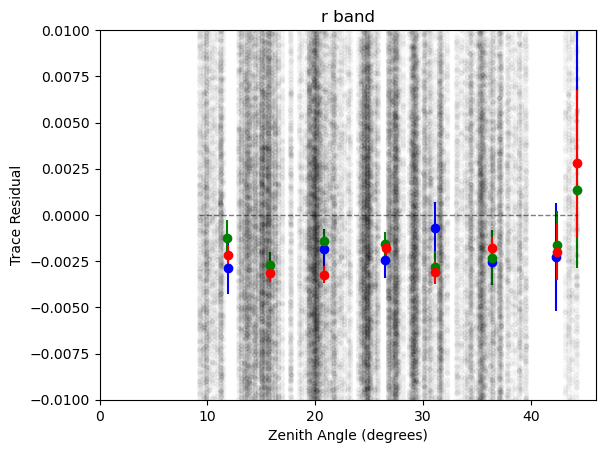

r observations: 86870 total, 86551 good


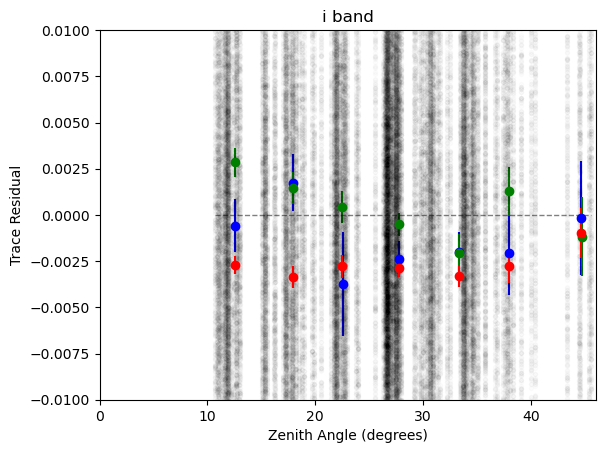

i observations: 86870 total, 86551 good


/tmp/ipykernel_53/2690295763.py:55: UserWarning: Warning: converting a masked element to nan.
  newx[i] = np.mean(x[mask])


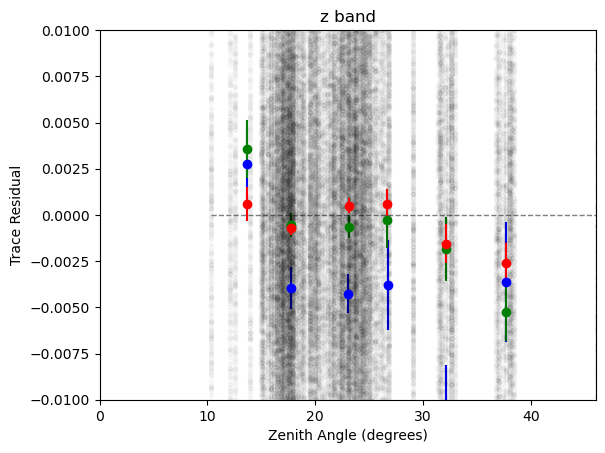

z observations: 86870 total, 86551 good


In [21]:
# Plot trace residuals
for band in 'ugrizy':
    band_mask = (master['band_1'] == band)  #* (master['raErr'] < 0.01/3600) * (master['decErr'] < 0.01/3600)

    if np.sum(band_mask) > 0:

        for i in [1, 2, 3]:

            full_mask = band_mask * (master[color_label] > color_bin_edges[i][0]) *  (master[color_label] < color_bin_edges[i][1])
            airmass = master[full_mask]['airmass']
            z = np.arccos(1 / airmass) * 180 / np.pi
    
    
            trace = master['aaIxx'][full_mask] + master['aaIyy'][full_mask]
            tracePSF = master['aaIxxPSF'][full_mask] + master['aaIyyPSF'][full_mask]
            
            plt.plot(z, (trace - tracePSF)/trace,  ls = '', marker = '.', alpha = 0.01, color = 'k') #, label = 'e1 (zenith axis)')
            # plt.plot(z, e2,  ls = '', marker = '.', alpha = 0.01, color = 'k', label = 'e2 (azimuthal axis)')
    
            bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
            
            mask = np.isnan(trace)
            z_bin1, trace_binned, trace_err = rebin(z[~mask], (trace[~mask] - tracePSF[~mask])/trace[~mask], 5)#, newx_edges = bin_edges)
    
            
            plt.errorbar(z_bin1, trace_binned, yerr = trace_err, ls = '', marker = 'o', label  = f'Average Trace (bin = {i})')
            # plt.errorbar(z_bin2, e2_binned, yerr = e2_err, ls = '', marker = 'o', color = 'k', label = 'Average e2')

       
        z_temp = np.linspace(min(z), max(z), 20) 
        # plt.plot(z_temp, dR_model(z_temp, *popt) , 'k--', linewidth = 2, label = 'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)), 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        # plt.plot(zeniths, diff / 3600, 'g.-', label = 'Simulated residual of a 7500 K star (reference: 4000 K star)')
        plt.ylim(-0.01, 0.01)
        plt.xlim(0, 46)
        plt.title(f'{band} band')
        plt.xlabel('Zenith Angle (degrees)')
        plt.ylabel('Trace Residual')
        # plt.legend()
    
        plt.show()
        plt.close()

        print(f'{band} observations: {len(e1)} total, {len(e1[~np.isnan(e1)])} good')

(array([ 62801.,  99553., 126123., 115380., 137418.,  94607., 102618.,
         59225.,   7013.,  15413.]),
 array([ 8.73009705, 12.6459233 , 16.56174955, 20.4775758 , 24.39340205,
        28.3092283 , 32.22505455, 36.1408808 , 40.05670705, 43.9725333 ,
        47.88835955]),
 <BarContainer object of 10 artists>)

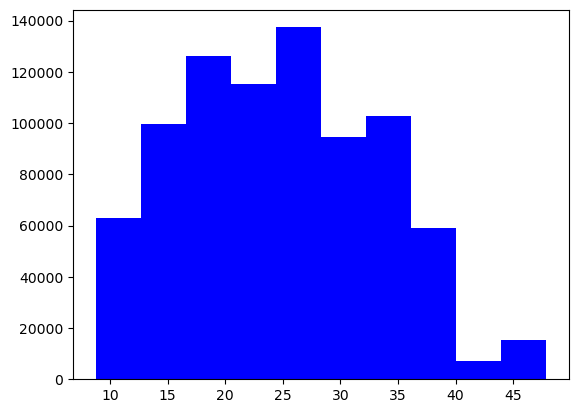

In [22]:
plt.hist(master['zenithDistance'])

221539
254
59401
50253
108587


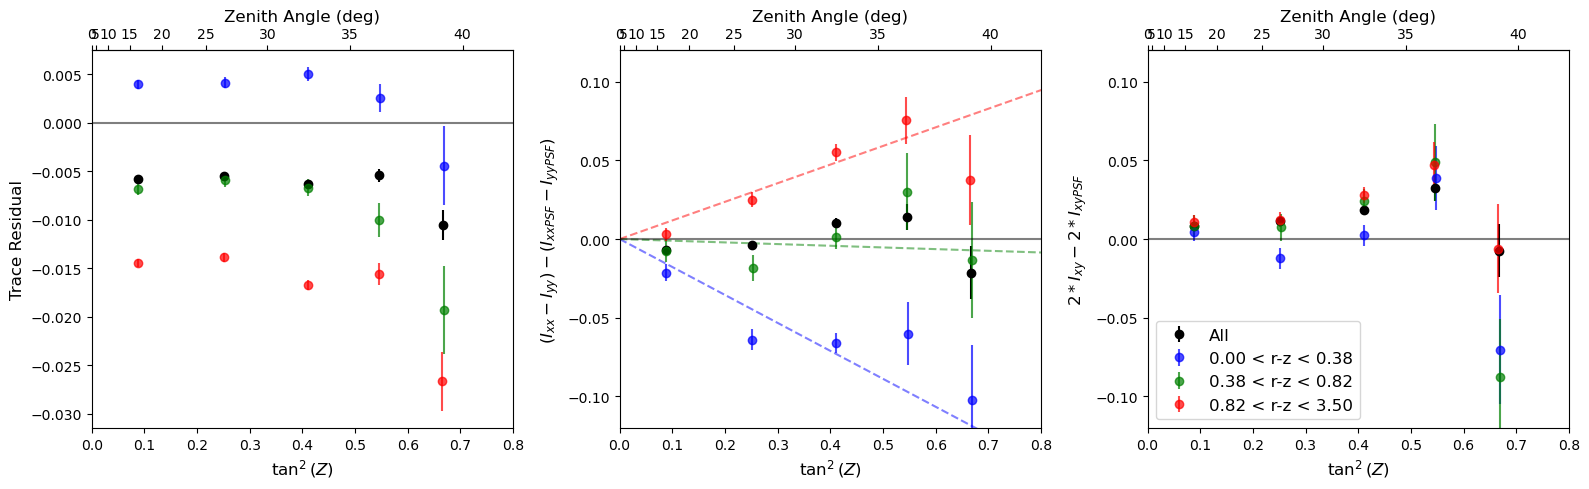

In [28]:
# 

color_label = 'rzColor'
# color_bin_edges = {1: [-0.7, 0.4], 2: [0.4, 2.4], 3: [2.4, 3.7], 4:[2.4, 3.5]}
# color_bin_edges = {1: [-0.7, 1.0], 2: [1.0, 2.0], 3: [2.0, 4.0], 4:[2.4, 3.5]}
color_bin_edges = {1: [0, 0.38], 2: [0.38, 0.82], 3: [0.82, 3.5]}

colors = {1: 'blue',2:  'green', 3: 'red'}

band_mask = ((master['band_1'] == 'g') * 
                (master['raErr'] < 0.05/3600) * 
                 (master['decErr'] < 0.05/3600) * 
                 (master['psfFluxErr']/master['psfFlux'] > 0) *
                (master['ixx'] < 20)*
                 (master['iyy'] < 20))

from scipy.optimize import curve_fit
def line_0(x,  p):
    return p * x

fig, ax = plt.subplots(1,3, figsize = (16, 5))




# ---- delta_e1
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

zeniths = np.tan(master['zenithDistance'][band_mask] * np.pi/180)**2

# #with normalization:
# de1 = master['e1'][band_mask] - master['e1PSF'][band_mask]
# de2 = master['e2'][band_mask] - master['e2PSF'][band_mask]
# dT_T = (master['aaIxx'][band_mask] + master['aaIyy'][band_mask] - master['aaIxxPSF'][band_mask] - master['aaIyyPSF'][band_mask])/(master['aaIxx'][band_mask] + master['aaIyy'][band_mask]) 

#without normalization
de1 = master['aaIxx'][band_mask] - master['aaIyy'][band_mask] - (master['aaIxxPSF'][band_mask] - master['aaIyyPSF'][band_mask])
de2 = 2*master['aaIxy'][band_mask] - 2*master['aaIxyPSF'][band_mask]
dT_T = (master['aaIxx'][band_mask] + master['aaIyy'][band_mask] - master['aaIxxPSF'][band_mask] - master['aaIyyPSF'][band_mask])/(master['aaIxx'][band_mask] + master['aaIyy'][band_mask]) 


# bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
bin_edges = np.linspace(0, 8, 6)/10
            

mask = np.isnan(de1)
zeniths_binned, de1_binned, de1err_binned = rebin(zeniths[~mask], de1[~mask], newx_edges = bin_edges)
ax1.errorbar(zeniths_binned, de1_binned, yerr = de1err_binned, ls = '', marker = 'o', c = 'k')
print(len(de1))
print(np.sum(mask))

mask = np.isnan(de2)
zeniths_binned, de2_binned, de2err_binned = rebin(zeniths[~mask], de2[~mask], newx_edges = bin_edges)
ax2.errorbar(zeniths_binned, de2_binned, yerr = de1err_binned, ls = '', marker = 'o', c = 'k', label = 'All')

mask = np.isnan(dT_T)
zeniths_binned, dT_binned, dTerr_binned = rebin(zeniths[~mask], dT_T[~mask], newx_edges = bin_edges)
ax0.errorbar(zeniths_binned, dT_binned, yerr = dTerr_binned, ls = '', marker = 'o', c = 'k')



labels = {1: '0.00 < r-z < 0.38', 2: '0.38 < r-z < 0.82', 3: '0.82 < r-z < 3.50'}

for i in [1, 2, 3]:
    full_mask = band_mask * (master[color_label] > color_bin_edges[i][0]) *  (master[color_label] < color_bin_edges[i][1])

    zeniths = np.tan(master['zenithDistance'][full_mask]* np.pi/180)**2

    #with normalization
    # de1 = master['e1'][full_mask] - master['e1PSF'][full_mask]
    # de2 = master['e2'][full_mask] - master['e2PSF'][full_mask]
    # dT_T = (master['aaIxx'][full_mask] + master['aaIyy'][full_mask] - master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])/(master['aaIxx'][full_mask] + master['aaIyy'][full_mask]) 

    #without normalization
    de1 = master['aaIxx'][full_mask] - master['aaIyy'][full_mask] - (master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])
    de2 = 2*master['aaIxy'][full_mask] - 2*master['aaIxyPSF'][full_mask]
    dT_T = (master['aaIxx'][full_mask] + master['aaIyy'][full_mask] - master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])/(master['aaIxx'][full_mask] + master['aaIyy'][full_mask]) 


    
    # bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
    bin_edges = np.linspace(0, 8, 6)/10

    
    mask = np.isnan(dT_T)
    zeniths_binned, dT_binned, dTerr_binned = rebin(zeniths[~mask], dT_T[~mask], newx_edges = bin_edges)
    ax0.errorbar(zeniths_binned, dT_binned, yerr = dTerr_binned, ls = '', marker = 'o', alpha = 0.7)
    
    mask = np.isnan(de1)
    print(len(de1[~mask]))
    zeniths_binned, de1_binned, de1err_binned = rebin(zeniths[~mask], de1[~mask], newx_edges = bin_edges)
    ax1.errorbar(zeniths_binned, de1_binned, yerr = de1err_binned, ls = '', marker = 'o', alpha = 0.7)
    
    popt, pcov = curve_fit(line_0, zeniths_binned, de1_binned, sigma = de1err_binned)
    ax1.plot(np.linspace(0, 1), line_0(np.linspace(0, 1), popt), c = colors[i], alpha = 0.5, ls = '--')
    # ax1.scatter(zeniths, de1, alpha = 0.01, marker = '.')

    mask = np.isnan(de2)
    zeniths_binned, de2_binned, de2err_binned = rebin(zeniths[~mask], de2[~mask], newx_edges = bin_edges)
    ax2.errorbar(zeniths_binned, de2_binned, yerr = de1err_binned, ls = '', marker = 'o', alpha = 0.7, label = labels[i])
    
    # popt, pcov = curve_fit(line_0, zeniths_binned, de2_binned, sigma = de2err_binned)
    # ax2.plot(np.linspace(0, 1), line_0(np.linspace(0, 1), popt), c = colors[i], alpha = 0.5, ls = '--')


for ax_ in ax:
    ax_.axhline(0, c = 'k', alpha = 0.5)
    ax_.set_xlabel(r'$\tan^2(Z)$', fontsize = 12)
    ax_.set_xlim(0, 0.8)

# ax1.set_ylim(-4e-3, 4e-3)
# ax2.set_ylim(-4e-3, 4e-3)

ax1.set_ylim(-0.12,0.12)
ax2.set_ylim(-0.12,0.12)

def tan2(z):
    z = z * np.pi/180
    return (np.tan(z)**2)

def arctan2(tan2):
    return np.arctan(np.sqrt(tan2)) * 180/np.pi

for ax_ in ax:
    secax = ax_.secondary_xaxis(
        "top",
        functions=(arctan2, tan2))
    
    secax.set_xlabel("Zenith Angle (deg)", fontsize = 12)


ax0.set_ylabel('Trace Residual', fontsize = 12)
# ax1.set_ylabel(r'$\delta e_1$', fontsize = 12)
# ax2.set_ylabel(r'$\delta e_2$', fontsize = 12)
ax1.set_ylabel(r'$(I_{xx} - I_{yy}) - (I_{xxPSF} - I_{yyPSF})$', fontsize = 12)
ax2.set_ylabel(r'$2*I_{xy} - 2*I_{xyPSF}$', fontsize = 12)
ax2.legend(loc = 'lower left', fontsize = 12)

fig.tight_layout()

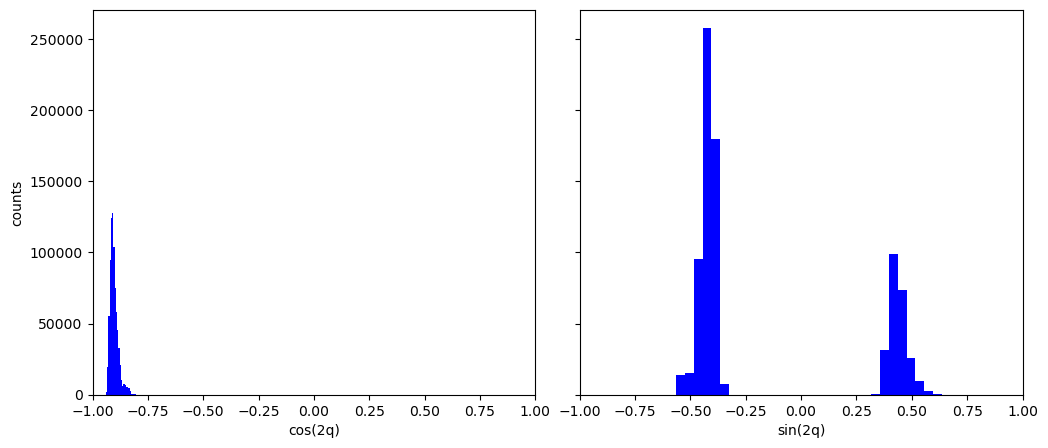

Text(0, 0.5, 'Frequency')

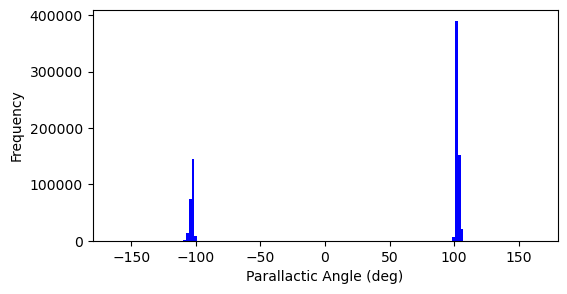

In [133]:
# plt.hist(np.tan(master['zenithDistance'][band_mask]*np.pi/180)**2)
fig, ax = plt.subplots(1, 2, sharey = True, figsize = (12, 5))
fig.subplots_adjust(wspace = 0.1)

band_mask = ((master['raErr'] < 0.05/3600) * 
                 (master['decErr'] < 0.05/3600) * 
                 (master['psfFluxErr']/master['psfFlux'] > 0) *
                (master['ixx'] < 20)*
                 (master['iyy'] < 20))

qs = np.cos(2*master['q'][band_mask]) #* 180/np.pi
ax[0].hist(qs, 30)

qs = np.sin(2*master['q'][band_mask]) #* 180/np.pi
ax[1].hist(qs, 30)

ax[0].set_ylabel('counts')
ax[0].set_xlabel('cos(2q)')
ax[1].set_xlabel('sin(2q)')
ax[0].set_xlim(-1, 1)
ax[1].set_xlim(-1, 1)
# plt.hist(master['q'][band_mask] * 180/np.pi, 60)
plt.show()
plt.close()

fig = plt.figure(figsize = (6, 3))
qs = master['q'][band_mask]* 180/np.pi

mask = qs > 180
qs[mask] = qs[mask] - 360
plt.hist(qs, 100)
plt.xlim(-180, 180)
plt.xlabel('Parallactic Angle (deg)')
plt.ylabel('Frequency')

(array([ 59392.,  50235., 109433.]),
 array([0.  , 0.38, 0.82, 3.5 ]),
 <BarContainer object of 3 artists>)

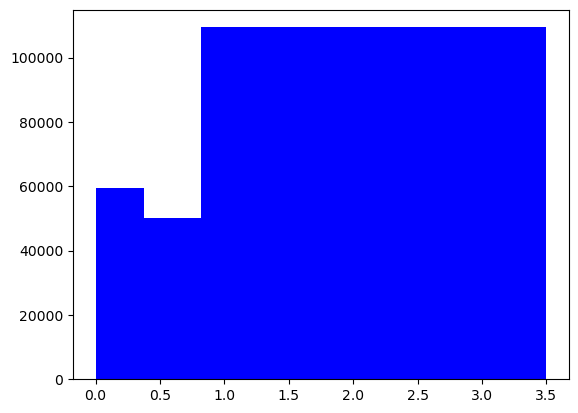

In [137]:
# 

color_label = 'rzColor'
# color_bin_edges = {1: [-0.7, 0.4], 2: [0.4, 2.4], 3: [2.4, 3.7], 4:[2.4, 3.5]}
# color_bin_edges = {1: [-0.7, 1.0], 2: [1.0, 2.0], 3: [2.0, 4.0], 4:[2.4, 3.5]}
color_bin_edges = {1: [0, 0.38], 2: [0.38, 0.82], 3: [0.82, 3.5]}

colors = {1: 'blue',2:  'green', 3: 'red'}

band_mask = ((master['band_1'] == 'g') * 
                (master['raErr'] < 0.05/3600) * 
                 (master['decErr'] < 0.05/3600) * 
                 (master['psfFluxErr']/master['psfFlux'] > 0) *
                (master['ixx'] < 20)*
                 (master['iyy'] < 20))

from scipy.optimize import curve_fit
def line_0(x,  p):
    return p * x

fig, ax = plt.subplots(1,3, figsize = (16, 5))




# ---- delta_e1
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

zeniths = np.tan(master['zenithDistance'][band_mask] * np.pi/180)**2

dR1 = 

# bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
bin_edges = np.linspace(0, 8, 6)/10
            

mask = np.isnan(de1)
zeniths_binned, de1_binned, de1err_binned = rebin(zeniths[~mask], de1[~mask], newx_edges = bin_edges)
ax1.errorbar(zeniths_binned, de1_binned, yerr = de1err_binned, ls = '', marker = 'o', c = 'k')
print(len(de1))
print(np.sum(mask))

mask = np.isnan(de2)
zeniths_binned, de2_binned, de2err_binned = rebin(zeniths[~mask], de2[~mask], newx_edges = bin_edges)
ax2.errorbar(zeniths_binned, de2_binned, yerr = de1err_binned, ls = '', marker = 'o', c = 'k', label = 'All')

mask = np.isnan(dT_T)
zeniths_binned, dT_binned, dTerr_binned = rebin(zeniths[~mask], dT_T[~mask], newx_edges = bin_edges)
ax0.errorbar(zeniths_binned, dT_binned, yerr = dTerr_binned, ls = '', marker = 'o', c = 'k')



labels = {1: '0.00 < r-z < 0.38', 2: '0.38 < r-z < 0.82', 3: '0.82 < r-z < 3.50'}

for i in [1, 2, 3]:
    full_mask = band_mask * (master[color_label] > color_bin_edges[i][0]) *  (master[color_label] < color_bin_edges[i][1])

    zeniths = np.tan(master['zenithDistance'][full_mask]* np.pi/180)**2

    #with normalization
    # de1 = master['e1'][full_mask] - master['e1PSF'][full_mask]
    # de2 = master['e2'][full_mask] - master['e2PSF'][full_mask]
    # dT_T = (master['aaIxx'][full_mask] + master['aaIyy'][full_mask] - master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])/(master['aaIxx'][full_mask] + master['aaIyy'][full_mask]) 

    #without normalization
    de1 = master['aaIxx'][full_mask] - master['aaIyy'][full_mask] - (master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])
    de2 = 2*master['aaIxy'][full_mask] - 2*master['aaIxyPSF'][full_mask]
    dT_T = (master['aaIxx'][full_mask] + master['aaIyy'][full_mask] - master['aaIxxPSF'][full_mask] - master['aaIyyPSF'][full_mask])/(master['aaIxx'][full_mask] + master['aaIyy'][full_mask]) 


    
    # bin_edges = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
    bin_edges = np.linspace(0, 8, 6)/10

    
    mask = np.isnan(dT_T)
    zeniths_binned, dT_binned, dTerr_binned = rebin(zeniths[~mask], dT_T[~mask], newx_edges = bin_edges)
    ax0.errorbar(zeniths_binned, dT_binned, yerr = dTerr_binned, ls = '', marker = 'o', alpha = 0.7)
    
    mask = np.isnan(de1)
    print(len(de1[~mask]))
    zeniths_binned, de1_binned, de1err_binned = rebin(zeniths[~mask], de1[~mask], newx_edges = bin_edges)
    ax1.errorbar(zeniths_binned, de1_binned, yerr = de1err_binned, ls = '', marker = 'o', alpha = 0.7)
    
    popt, pcov = curve_fit(line_0, zeniths_binned, de1_binned, sigma = de1err_binned)
    ax1.plot(np.linspace(0, 1), line_0(np.linspace(0, 1), popt), c = colors[i], alpha = 0.5, ls = '--')
    # ax1.scatter(zeniths, de1, alpha = 0.01, marker = '.')

    mask = np.isnan(de2)
    zeniths_binned, de2_binned, de2err_binned = rebin(zeniths[~mask], de2[~mask], newx_edges = bin_edges)
    ax2.errorbar(zeniths_binned, de2_binned, yerr = de1err_binned, ls = '', marker = 'o', alpha = 0.7, label = labels[i])
    
    # popt, pcov = curve_fit(line_0, zeniths_binned, de2_binned, sigma = de2err_binned)
    # ax2.plot(np.linspace(0, 1), line_0(np.linspace(0, 1), popt), c = colors[i], alpha = 0.5, ls = '--')


for ax_ in ax:
    ax_.axhline(0, c = 'k', alpha = 0.5)
    ax_.set_xlabel(r'$\tan^2(Z)$', fontsize = 12)
    ax_.set_xlim(0, 0.8)

# ax1.set_ylim(-4e-3, 4e-3)
# ax2.set_ylim(-4e-3, 4e-3)

ax1.set_ylim(-0.12,0.12)
ax2.set_ylim(-0.12,0.12)

def tan2(z):
    z = z * np.pi/180
    return (np.tan(z)**2)

def arctan2(tan2):
    return np.arctan(np.sqrt(tan2)) * 180/np.pi

for ax_ in ax:
    secax = ax_.secondary_xaxis(
        "top",
        functions=(arctan2, tan2))
    
    secax.set_xlabel("Zenith Angle (deg)", fontsize = 12)


ax0.set_ylabel('Trace Residual', fontsize = 12)
# ax1.set_ylabel(r'$\delta e_1$', fontsize = 12)
# ax2.set_ylabel(r'$\delta e_2$', fontsize = 12)
ax1.set_ylabel(r'$(I_{xx} - I_{yy}) - (I_{xxPSF} - I_{yyPSF})$', fontsize = 12)
ax2.set_ylabel(r'$2*I_{xy} - 2*I_{xyPSF}$', fontsize = 12)
ax2.legend(loc = 'lower left', fontsize = 12)

fig.tight_layout()

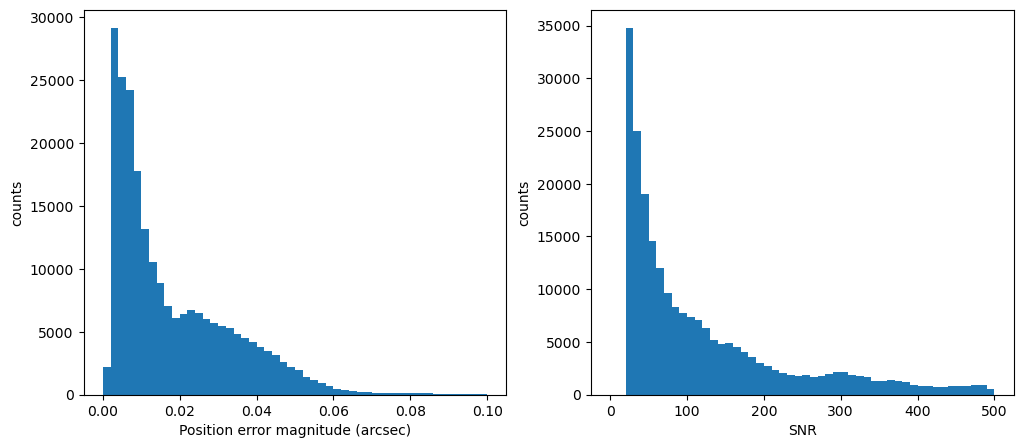

In [43]:

fig, ax = plt.subplots(1,2, figsize = (12, 5))

band_mask = master['band_1'] == 'g'

ax[0].hist(np.sqrt(master['raErr'][band_mask]**2 + master['decErr'][band_mask]**2)*3600, 50, range = (0, 0.1)) # magnitude of position error
ax[0].set_xlabel('Position error magnitude (arcsec)')
ax[0].set_ylabel('counts')

ax[1].hist(master['psfFlux'][band_mask]/master['psfFluxErr'][band_mask], 50, range = (0, 500)) # magnitude of position error
ax[1].set_xlabel('SNR')
ax[1].set_ylabel('counts')

plt.show()